# Stimuli → Brain Alignment (Pythia scaling)

Windowed ridge encoding of Houston iEEG from Pythia hidden states, swept over **four model sizes** and **training checkpoints**.

**Outputs:** per-model mean alignment vs. step; cross-model scaling summary (params & tokens).

**Run order:** setup → load events → helpers → extractors → sweep → plots.

In [ ]:
from collections import Counter, OrderedDict
from pathlib import Path
import warnings
import typing as tp

from joblib import Parallel, delayed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr as _spearmanr
from scipy.linalg import LinAlgWarning
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import KFold
from sklearn.preprocessing import RobustScaler

import neuralset as ns
from neuralset.events.transforms.text import AddConcatenationContext
from neuralset.extractors.neuro import IeegExtractor
from neuralset.extractors.text import HuggingFaceText
from exca import MapInfra

# ── Paths ──────────────────────────────────────────────────────────────────
BIDS_ROOT  = Path("bids/") # your local path to the bids folder we need ot have BIDS_ROOT/subject
SUBJECT    = "sub-TS304C"
TASK       = "auditory"
DEVICE     = "cpu"
CACHE_DIR  = ".cache"

# Pythia scaling family (architecture from model cards)
MODELS: OrderedDict[str, dict] = OrderedDict([
    ("EleutherAI/pythia-14m", dict(
        label="Pythia-14M", n_params=14e6, n_layers=7,
        n_heads=4, hidden=128, batch_tokens=2e6, lr=1e-3, deduped=False,
    )),
    ("EleutherAI/pythia-31m", dict(
        label="Pythia-31M", n_params=31e6, n_layers=7,
        n_heads=8, hidden=256, batch_tokens=2e6, lr=1e-3, deduped=False,
    )),
    ("EleutherAI/pythia-70m-deduped", dict(
        label="Pythia-70M-Deduped", n_params=70e6, n_layers=7,
        n_heads=8, hidden=512, batch_tokens=2e6, lr=1e-3, deduped=True,
    )),
    ("EleutherAI/pythia-160m-deduped", dict(
        label="Pythia-160M-Deduped", n_params=160e6, n_layers=13,
        n_heads=12, hidden=768, batch_tokens=2e6, lr=6e-4, deduped=True,
    )),
])

# Log-spaced training checkpoints (HF revisions step{N})
STEPS = [
    0, 128, 256, 512, 1000, 2000, 4000, 8000,
    16_000, 32_000, 64_000, 128_000, 143_000,
]
TOKENS_PER_STEP = 2**21  # Pythia: ~2M tokens per optimizer step

# ── iEEG preprocessing ────────────────────────────────────────────────────
TMIN_EXTRACT  = -0.1
TMIN          =  0.0
TMAX          =  0.8
FREQ_FILTER   = (70, 150)
NOTCH_FREQ    = 60
BASELINE      = (-0.1, -0.05)
BASELINE_MODE = "logratio"
CLIP_IQR      = 5.0
WINDOW_SIZE   = 0.2
STEP_SIZE     = 0.05
ALPHAS        = np.logspace(1.5, 5, 7)
N_SPLITS      = 5
N_JOBS        = -1

ELECTRODE_CHANNEL = 0
BEST_LAYER_MODE = -1

assert BIDS_ROOT.exists(), f"BIDS root not found: {BIDS_ROOT}"
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})


In [30]:
# ── Houston BIDS → NeuralSet events (inline loader, no neuroai) ───────────────
from neuralset.events import utils as ns_ev_utils

_WORD_EVENTS = {"word_onset", "first_word_onset", "last_word_onset", "target_onset"}
_META_COLS = (
    "Trial", "RT", "violation", "Embedding", "Base_condition",
    "sentence", "structure", "congruency", "response",
)


def load_houston_events(bids_root: Path, subject: str, task: str) -> pd.DataFrame:
    """Build a NeuralSet events DataFrame from one Houston auditory run."""
    base = bids_root / subject / "ses-01" / "ieeg"
    vhdr = base / f"{subject}_ses-01_task-{task}_acq-macro_run-01_ieeg.vhdr"
    ev_path = base / f"{subject}_ses-01_task-{task}_acq-macro_run-01_events.tsv"
    if not vhdr.exists() or not ev_path.exists():
        raise FileNotFoundError(f"Missing BIDS files under {base}")

    ev = pd.read_csv(ev_path, sep="\t", dtype=str, na_values=["n/a"])
    ev["onset"] = pd.to_numeric(ev["onset"], errors="coerce")
    ev["RT"] = pd.to_numeric(ev.get("RT"), errors="coerce")

    rows: list[dict] = [
        {"type": "Ieeg", "filepath": str(vhdr), "start": 0.0, "duration": 0.0},
    ]
    for r in ev[ev["Event"].isin(_WORD_EVENTS)].itertuples(index=False):
        tok = str(getattr(r, "Token", "")).strip()
        if not tok or tok == "+" or pd.isna(r.onset):
            continue
        extra = {"Event": str(r.Event)}
        for col in _META_COLS:
            val = getattr(r, col, None)
            if val is not None and not (isinstance(val, float) and pd.isna(val)):
                extra[col] = val
        rows.append({
            "type": "Word",
            "start": float(r.onset),
            "duration": 0.5,
            "text": tok,
            "language": "english",
            **extra,
        })
    df = pd.DataFrame(rows)
    timeline = {"subject": subject, "task": task, "session": "01", "run": "01"}
    study_name = "HoustonTutorial"
    df["subject"] = f"{study_name}/{subject}"
    df["timeline"] = study_name + ":" + ",".join(
        f"{k}={v}" for k, v in sorted(timeline.items())
    )
    df["study"] = study_name
    for key, value in timeline.items():
        if key not in df.columns:
            df[key] = str(value)
    return ns_ev_utils.standardize_events(df, auto_fill=False)


events = load_houston_events(BIDS_ROOT, SUBJECT, TASK)
events = AddConcatenationContext(event_type="Word", split_field="Trial")(events)

targets = events.query("type == 'Word' and Event == 'target_onset'")
print(f"{len(targets)} target-onset trials  |  {(events.type == 'Ieeg').sum()} iEEG file(s)")
targets[["text", "context", "RT", "Base_condition"]].head(3)


90 target-onset trials  |  1 iEEG file(s)


,text,context,RT,Base_condition
6,detest,The lawyer that this banker detest,1.29820,GDLD
13,love,These lawyers that these barbers love,0.98664,GSLS
20,prefer,The waiter near the athlete prefer,0.88610,GDLD


In [31]:
# ── Preprocessing helpers ─────────────────────────────────────────────────

def apply_baseline(ieeg, times, baseline=BASELINE, mode=BASELINE_MODE, eps=1e-12):
    """(n_trials, n_ch, n_t) → baseline-corrected array."""
    t0, t1 = baseline
    mask = (times >= t0) & (times < t1)
    ref  = ieeg[:, :, mask].mean(axis=2, keepdims=True)
    out  = ieeg.astype(np.float64, copy=True)
    if mode == "logratio":
        out = np.log(np.maximum(out, eps) / np.maximum(ref, eps))
    elif mode == "mean":
        out -= ref
    elif mode == "ratio":
        out /= np.maximum(ref, eps)
    return out.astype(np.float32)


def apply_iqr_clip(ieeg, clip=CLIP_IQR):
    """Clip per-trial-per-channel to ±clip × IQR."""
    out = ieeg.copy()
    for ci in range(ieeg.shape[1]):
        for ti in range(ieeg.shape[0]):
            x = out[ti, ci]
            q25, q75 = np.percentile(x, [25, 75])
            iqr = q75 - q25
            out[ti, ci] = np.clip(x, q25 - clip * iqr, q75 + clip * iqr)
    return out


def load_channel_names(bids_root, subject, task, drop_bads=True):
    p = (bids_root / subject / "ses-01" / "ieeg" /
         f"{subject}_ses-01_task-{task}_acq-macro_run-01_channels.tsv")
    df = pd.read_csv(p, sep="\t", dtype=str)
    mask = df["type"].str.upper().isin({"EEG", "SEEG", "ECOG"})
    if drop_bads and "status" in df.columns:
        mask &= df["status"].str.lower().str.strip() == "good"
    return df.loc[mask, "name"].tolist()


def load_electrode_meta(bids_root, subject, channel_names):
    for fname in [f"{subject}_ses-01_acq-macro_electrodes.tsv",
                  f"{subject}_ses-01_electrodes.tsv"]:
        p = bids_root / subject / "ses-01" / "ieeg" / fname
        if not p.exists():
            continue
        df = pd.read_csv(p, sep="\t", na_values=["n/a"], dtype=str).set_index("name")
        d  = df.to_dict("index")
        out = {}
        for ch in channel_names:
            e = d.get(ch, {})
            def _f(k): return float(e[k]) if k in e and e[k] not in (None, "", "nan") else np.nan
            out[ch] = {"x": _f("x"), "y": _f("y"), "z": _f("z"),
                       "region": e.get("roi") or e.get("location"),
                       "hemisphere": e.get("hemisphere")}
        return out
    return {ch: {"x": np.nan, "y": np.nan, "z": np.nan, "region": None} for ch in channel_names}


# ── Ridge regression (sliding window) ─────────────────────────────────────

def _fit_ridge(X_tr, y_tr, alphas):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=LinAlgWarning)
        warnings.filterwarnings("ignore", category=UserWarning, module=r"sklearn")
        if len(alphas) == 1:
            return Ridge(alpha=float(alphas[0])).fit(X_tr, y_tr)
        cv = 5 if len(X_tr) >= 15 else None
        return RidgeCV(alphas=alphas, cv=cv).fit(X_tr, y_tr)


def _ridge_chosen_alpha(model) -> float:
    if isinstance(model, RidgeCV):
        a = np.asarray(model.alpha_, dtype=float).ravel()
        return float(np.nanmedian(a)) if a.size else float("nan")
    return float(np.asarray(model.alpha, dtype=float).ravel()[0])


def summarize_alpha_choices(alpha_values) -> str:
    """Mode and top picks from all RidgeCV selections in a checkpoint step."""
    finite = [float(a) for a in alpha_values if np.isfinite(a)]
    if not finite:
        return "  chosen alpha: (no finite selections)"
    counts = Counter(finite)
    top = counts.most_common(5)
    med = float(np.median(finite))
    lines = [
        f"  chosen alpha: n={len(finite)}  median={med:.6g}",
        "    most common: " + ", ".join(f"{a:.6g} ({n}×)" for a, n in top),
    ]
    return "\n".join(lines)


def curve_mean_score(sr: np.ndarray) -> float:
    """Mean Spearman over time windows; -inf if no finite values."""
    if sr is None or not np.any(np.isfinite(sr)):
        return -np.inf
    with np.errstate(all="ignore"):
        return float(np.nanmean(sr))


def channels_to_fit(ch_names: list[str]) -> list[int]:
    """ELECTRODE_CHANNEL: None = all; int = index; str = channel name."""
    if ELECTRODE_CHANNEL is None:
        return list(range(len(ch_names)))
    if isinstance(ELECTRODE_CHANNEL, int):
        if not 0 <= ELECTRODE_CHANNEL < len(ch_names):
            raise IndexError(f"ELECTRODE_CHANNEL={ELECTRODE_CHANNEL} out of range (n={len(ch_names)})")
        return [ELECTRODE_CHANNEL]
    if isinstance(ELECTRODE_CHANNEL, str):
        if ELECTRODE_CHANNEL not in ch_names:
            raise ValueError(f"Unknown channel {ELECTRODE_CHANNEL!r}; example: {ch_names[:3]}")
        return [ch_names.index(ELECTRODE_CHANNEL)]
    raise TypeError("ELECTRODE_CHANNEL must be None, int, or str")


def ridge_windowed(X, y_ts, times,
                   window_size=WINDOW_SIZE, step_size=STEP_SIZE,
                   n_splits=N_SPLITS, alphas=ALPHAS):
    """Return (window_centers, spearmanr_curve, fold_alpha) for one electrode."""
    valid = np.isfinite(X).all(axis=1)
    X, y_ts = X[valid], y_ts[valid]

    starts  = np.arange(times[0], times[-1] - window_size + step_size * 0.5, step_size)
    centers = starts + window_size / 2
    n_win   = len(starts)
    nan_curve = np.full(n_win, np.nan)
    nan_alpha = np.full((n_splits, n_win), np.nan)

    if len(X) < n_splits:
        return centers, nan_curve, nan_alpha

    kf     = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    splits = list(kf.split(X))
    sc     = RobustScaler()
    Xtr_s  = {i: sc.fit_transform(X[tr]) for i, (tr, _) in enumerate(splits)}
    Xte_s  = {i: sc.transform(X[te])    for i, (_, te) in enumerate(splits)}

    fold_sr = np.full((n_splits, n_win), np.nan)
    fold_alpha = np.full((n_splits, n_win), np.nan)
    for wi, t0 in enumerate(starts):
        mask = (times >= t0) & (times < t0 + window_size)
        if not mask.any():
            continue
        y_win = y_ts[:, mask].mean(axis=1)
        for fi, (tr, te) in enumerate(splits):
            y_tr, y_te = y_win[tr], y_win[te]
            if not (np.isfinite(y_tr).all() and np.isfinite(y_te).all()):
                continue
            model = _fit_ridge(Xtr_s[fi], y_tr, alphas)
            fold_alpha[fi, wi] = _ridge_chosen_alpha(model)
            yp = model.predict(Xte_s[fi])
            if np.std(y_te) > 1e-8 and np.std(yp) > 1e-8:
                fold_sr[fi, wi] = float(_spearmanr(y_te, yp).statistic)

    with np.errstate(all="ignore"):
        sr = np.nanmedian(fold_sr, axis=0)
    return centers, sr, fold_alpha


def fit_one_electrode(ci, emb_np, ieeg_np, times, ch_names, meta_dict, n_layers):
    """Ridge encoding for one channel (picklable for joblib)."""
    ch = ch_names[ci]
    best_centers, best_sr, best_score = None, None, -np.inf
    alpha_picks: list[float] = []

    if isinstance(BEST_LAYER_MODE, int):
        layer_ids = [BEST_LAYER_MODE]
    else:
        layer_ids = range(n_layers)

    for li in layer_ids:
        centers, sr, fold_alpha = ridge_windowed(emb_np[:, li, :], ieeg_np[:, ci, :], times)
        alpha_picks.extend(fold_alpha[np.isfinite(fold_alpha)].tolist())
        score = curve_mean_score(sr)
        if score > best_score:
            best_centers, best_sr, best_score = centers, sr, score

    if best_sr is None:
        best_centers, best_sr, _ = ridge_windowed(emb_np[:, 0, :], ieeg_np[:, ci, :], times)

    return {
        "ci": ci,
        "ch": ch,
        "centers": best_centers,
        "sr": best_sr,
        "score": best_score,
        "meta": meta_dict.get(ch, {}),
        "alpha_picks": alpha_picks,
    }


print("Helpers defined.")


Helpers defined.


In [32]:
class CheckpointHFText(HuggingFaceText):
    revision: str = "main"
    def repo_exists(self): return True
    def _load_model(self, **kw): return super()._load_model(revision=self.revision, **kw)


TRIGGER_QUERY = "type == 'Word' and Event == 'target_onset'"


def _segment(events, extractors, cache_dir=CACHE_DIR):
    extract_duration = TMAX - TMIN_EXTRACT
    seg = ns.Segmenter(
        extractors=extractors,
        trigger_query=TRIGGER_QUERY,
        start=TMIN_EXTRACT, duration=extract_duration, drop_incomplete=True,
    )
    ds = seg.apply(events)
    ds.prepare()
    return ds.load_all()


def extract_ieeg(events, cache_dir=CACHE_DIR):
    """Load and preprocess iEEG once (shared across models/checkpoints)."""
    ieeg_extractor = IeegExtractor(
        event_types="Ieeg", picks=("data",),
        filter=FREQ_FILTER, apply_hilbert=True,
        notch_filter=NOTCH_FREQ, drop_bads=True,
        #infra=MapInfra(folder=f"{cache_dir}/ieeg", cluster=None),
    )
    batch = _segment(events, {"ieeg": ieeg_extractor}, cache_dir)
    ieeg_np = batch.data["ieeg"].float().numpy()
    n_times = ieeg_np.shape[-1]
    times = np.linspace(TMIN_EXTRACT, TMAX, n_times, endpoint=False)

    ch_names = load_channel_names(BIDS_ROOT, SUBJECT, TASK)
    n_ch = ieeg_np.shape[1]
    if len(ch_names) > n_ch:
        ch_names = ch_names[:n_ch]
    elif len(ch_names) < n_ch:
        ch_names += [f"ch{i}" for i in range(len(ch_names), n_ch)]

    ieeg_np = apply_baseline(ieeg_np, times)
    mask = (times >= TMIN) & (times < TMAX)
    ieeg_np = ieeg_np[:, :, mask]
    times = times[mask]
    ieeg_np = apply_iqr_clip(ieeg_np)
    meta = load_electrode_meta(BIDS_ROOT, SUBJECT, ch_names)
    return ieeg_np, times, ch_names, meta


def extract_embeddings(events, model_name, revision, cache_dir=CACHE_DIR):
    emb_extractor = CheckpointHFText(
        model_name=model_name, revision=revision,
        contextualized=True, event_types="Word", aggregation="trigger",
        layers="all", layer_aggregation=None,
        token_aggregation="mean", device=DEVICE,
        #infra=MapInfra(folder=f"{cache_dir}/emb/{model_name.replace('/', '_')}/{revision}", cluster=None),
    )
    batch = _segment(events, {"embeddings": emb_extractor}, cache_dir)
    return batch.data["embeddings"].float().numpy()


def mean_alignment_stats(curves: np.ndarray) -> tuple[float, float]:
    """Window-mean per electrode, then mean ± SEM across electrodes."""
    per_elec = np.nanmean(curves, axis=1)
    n = int(np.isfinite(per_elec).sum())
    mu = float(np.nanmean(per_elec)) if n else np.nan
    sem = float(np.nanstd(per_elec) / np.sqrt(n)) if n else np.nan
    return mu, sem


print(f"Models: {list(MODELS.keys())}")
print(f"Steps:  {STEPS}")


Models: ['EleutherAI/pythia-14m', 'EleutherAI/pythia-31m', 'EleutherAI/pythia-70m-deduped', 'EleutherAI/pythia-160m-deduped']
Steps:  [0, 128, 256, 512, 1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000, 143000]


In [ ]:
# ── Multi-model checkpoint sweep ───────────────────────────────────────────
# all_results[model_id][step] = {centers, curves, ch_names, meta}

events = load_houston_events(BIDS_ROOT, SUBJECT, TASK)
events = AddConcatenationContext(event_type="Word", split_field="Trial")(events)

print("Loading iEEG (once)…")
ieeg_np, times, ch_names, meta = extract_ieeg(events)
channel_indices = channels_to_fit(ch_names)
print(f"  trials={ieeg_np.shape[0]}  channels={ieeg_np.shape[1]}  "
      f"fitting {len(channel_indices)} electrode(s)")

all_results: dict[str, dict[int, dict]] = {}

for model_id, info in MODELS.items():
    print(f"\n{'=' * 60}\n{info['label']}  ({model_id})\n{'=' * 60}")
    model_results: dict[int, dict] = {}

    for step in STEPS:
        revision = f"step{step}"
        print(f"── {revision} ──")
        emb_np = extract_embeddings(events, model_id, revision)
        n_layers = emb_np.shape[1]
        print(f"  layers={n_layers}  emb_dim={emb_np.shape[-1]}")

        fitted = Parallel(n_jobs=N_JOBS, backend="loky")(
            delayed(fit_one_electrode)(ci, emb_np, ieeg_np, times, ch_names, meta, n_layers)
            for ci in channel_indices
        )
        fitted.sort(key=lambda r: r["ci"])
        all_curves = [r["sr"] for r in fitted]
        step_alphas = [a for r in fitted for a in r["alpha_picks"]]

        if len(channel_indices) == 1:
            r0 = fitted[0]
            print(f"    {r0['ch']}  layer_score={r0['score']:.4f}")
        print(summarize_alpha_choices(step_alphas))

        curves = np.array(all_curves)
        mu, sem = mean_alignment_stats(curves)
        model_results[step] = {
            "centers": fitted[0]["centers"],
            "curves": curves,
            "ch_names": ch_names,
            "meta": [r["meta"] for r in fitted],
            "mean_alignment": mu,
            "sem_alignment": sem,
            "tokens_seen": step * TOKENS_PER_STEP,
        }
        print(f"  mean alignment (window-mean → electrode mean) = {mu:.4f} ± {sem:.4f}")

    all_results[model_id] = model_results

print("Sweep complete.")


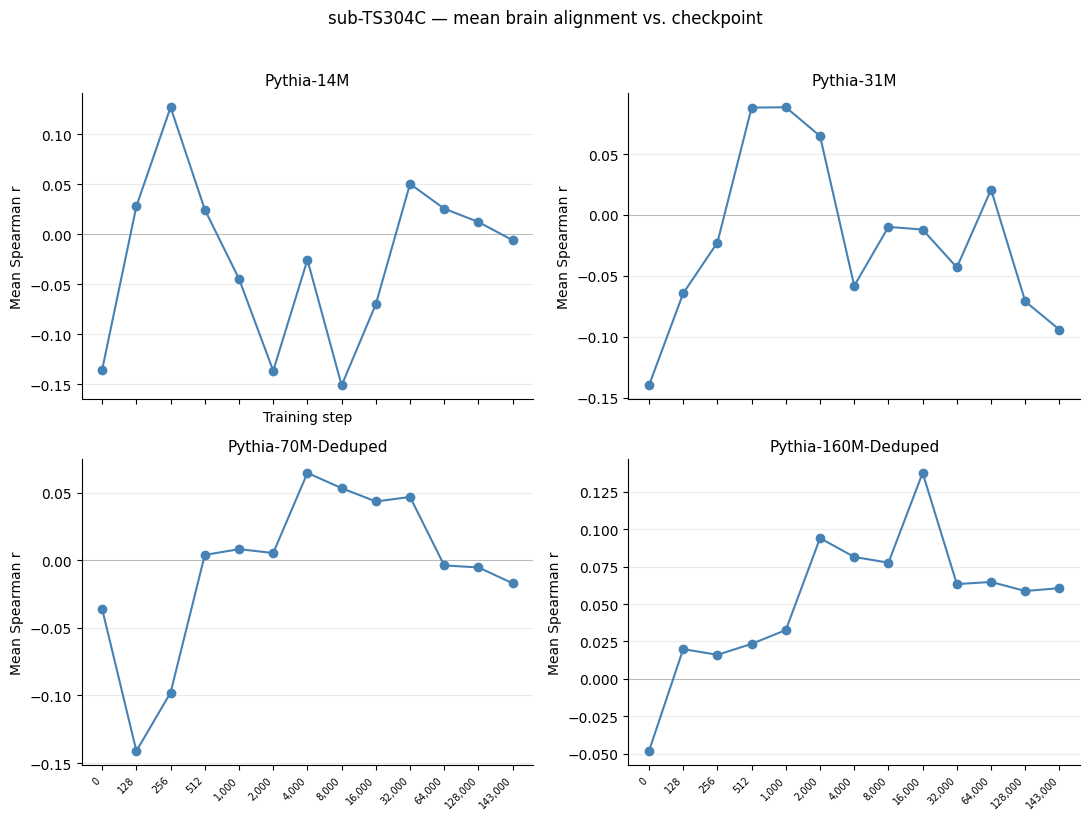

In [34]:
# ── Per-model: mean alignment vs. training step ─────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
axes_flat = axes.ravel()

for ax, (model_id, info) in zip(axes_flat, MODELS.items()):
    res = all_results[model_id]
    steps = [s for s in STEPS if s in res]
    means = [res[s]["mean_alignment"] for s in steps]
    sems = [res[s]["sem_alignment"] for s in steps]
    x = np.arange(len(steps))

    ax.errorbar(x, means, yerr=sems, fmt="o-", color="steelblue", ms=6, capsize=3, lw=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s:,}" for s in steps], fontsize=7, rotation=45, ha="right")
    ax.set_title(info["label"], fontsize=11)
    ax.set_ylabel("Mean Spearman r")
    ax.axhline(0, color="k", lw=0.5, alpha=0.3)
    ax.grid(axis="y", alpha=0.25)

axes_flat[0].set_xlabel("Training step")
fig.suptitle(f"{SUBJECT} — mean brain alignment vs. checkpoint", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("alignment_per_model_steps.png", dpi=150, bbox_inches="tight")
plt.show()


step,0,128,256,512,1000,2000,4000,8000,16000,32000,64000,128000,143000
label,,,,,,,,,,,,,
Pythia-14M,-0.1355,0.0279,0.1269,0.0245,-0.0447,-0.1366,-0.0256,-0.1512,-0.0701,0.0503,0.0255,0.0121,-0.0061
Pythia-160M-Deduped,-0.0480,0.0199,0.0161,0.0234,0.0326,0.0939,0.0814,0.0776,0.1374,0.0633,0.0647,0.0587,0.0606
Pythia-31M,-0.1400,-0.0644,-0.0226,0.0882,0.0885,0.0649,-0.0582,-0.0098,-0.0120,-0.0431,0.0209,-0.0710,-0.0942
Pythia-70M-Deduped,-0.0361,-0.1411,-0.0979,0.0039,0.0082,0.0053,0.0645,0.0533,0.0434,0.0468,-0.0039,-0.0053,-0.0171


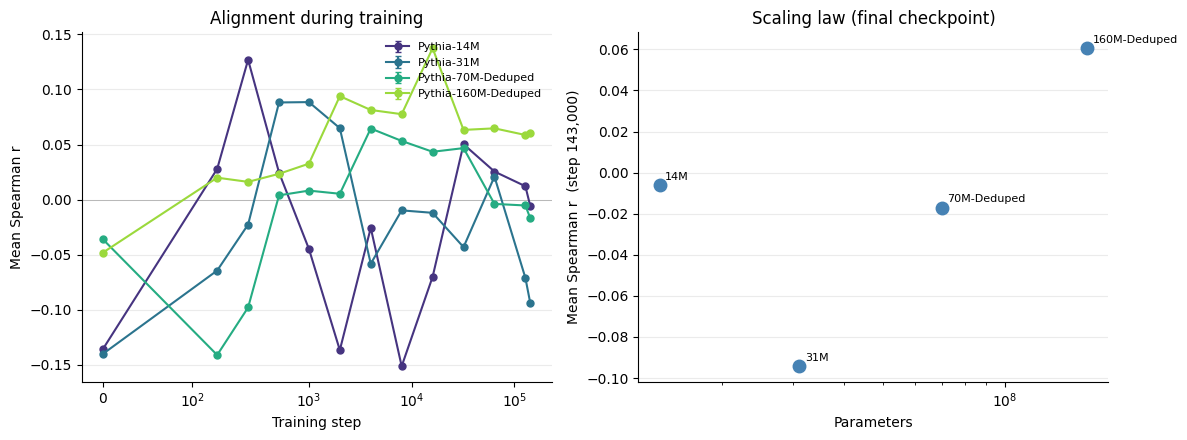

Saved alignment_scaling_results.csv  (52 rows)


In [35]:
# ── Scaling summary ─────────────────────────────────────────────────────────
from IPython.display import display

rows = []
for model_id, info in MODELS.items():
    for step in STEPS:
        r = all_results[model_id].get(step)
        if r is None:
            continue
        rows.append({
            "model_id": model_id,
            "label": info["label"],
            "n_params": info["n_params"],
            "step": step,
            "tokens_seen": r["tokens_seen"],
            "mean_alignment": r["mean_alignment"],
            "sem_alignment": r["sem_alignment"],
        })
df = pd.DataFrame(rows)
display(df.pivot_table(index="label", columns="step", values="mean_alignment").round(4))

FINAL_STEP = STEPS[-1]
final_df = df[df["step"] == FINAL_STEP].sort_values("n_params")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: training curves — all models on one axis
ax = axes[0]
palette = plt.cm.viridis(np.linspace(0.15, 0.85, len(MODELS)))
for (model_id, info), color in zip(MODELS.items(), palette):
    sub = df[df["model_id"] == model_id].sort_values("step")
    ax.errorbar(
        sub["step"], sub["mean_alignment"], yerr=sub["sem_alignment"],
        fmt="o-", label=info["label"], color=color, ms=5, capsize=2, lw=1.5,
    )
ax.set_xscale("symlog", linthresh=128)
ax.set_xlabel("Training step")
ax.set_ylabel("Mean Spearman r")
ax.set_title("Alignment during training")
ax.legend(fontsize=8, frameon=False)
ax.axhline(0, color="k", lw=0.5, alpha=0.3)
ax.grid(axis="y", alpha=0.25)

# Right: scaling law at final checkpoint
ax2 = axes[1]
x = final_df["n_params"].values
y = final_df["mean_alignment"].values
yerr = final_df["sem_alignment"].values
ax2.errorbar(x, y, yerr=yerr, fmt="o", color="steelblue", ms=9, capsize=4, lw=0)
for _, row in final_df.iterrows():
    ax2.annotate(row["label"].replace("Pythia-", ""), (row["n_params"], row["mean_alignment"]),
                 textcoords="offset points", xytext=(4, 4), fontsize=8)
if np.all(x > 0) and np.all(y > 0):
    log_x, log_y = np.log10(x), np.log10(y)
    slope, intercept = np.polyfit(log_x, log_y, 1)
    x_line = np.logspace(np.log10(x.min()), np.log10(x.max()), 50)
    y_line = 10 ** (slope * np.log10(x_line) + intercept)
    ax2.plot(x_line, y_line, "--", color="gray", lw=1.5,
             label=f"fit  slope={slope:.3f}")
    ax2.legend(fontsize=8, frameon=False)
ax2.set_xscale("log")
ax2.set_xlabel("Parameters")
ax2.set_ylabel(f"Mean Spearman r  (step {FINAL_STEP:,})")
ax2.set_title("Scaling law (final checkpoint)")
ax2.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("alignment_scaling_summary.png", dpi=150, bbox_inches="tight")
plt.show()

df.to_csv("alignment_scaling_results.csv", index=False)
print(f"Saved alignment_scaling_results.csv  ({len(df)} rows)")


In [36]:
plot_rows = []
for model_id, info in MODELS.items():
    res = all_results[model_id]
    steps = [s for s in STEPS if s in res]
    for s in steps:
        plot_rows.append({
            "model_id": model_id,
            "label": info["label"],
            "n_params": info["n_params"],
            "step": s,
            "tokens_seen": res[s]["tokens_seen"],
            "mean_alignment": res[s]["mean_alignment"],
            "sem_alignment": res[s]["sem_alignment"],
        })

plot_df = pd.DataFrame(plot_rows)
plot_df.to_csv("alignment_per_model_steps_plot_data.csv", index=False)
print(f"Saved {len(plot_df)} rows → alignment_per_model_steps_plot_data.csv")

Saved 52 rows → alignment_per_model_steps_plot_data.csv
